Baixar dados

In [17]:
import kagglehub

path = kagglehub.dataset_download("vardhansiramdasu/fraudulent-transactions-prediction")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\luana\.cache\kagglehub\datasets\vardhansiramdasu\fraudulent-transactions-prediction\versions\1


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler

#### Análise exploratória inicial do dataset

In [19]:
df = pd.read_csv(path + "/Fraud.csv")

# Informações sobre o dataset
print(df.info())
print("\n")
# Mostrar as primeiras linhas
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None




,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [20]:
# Verificar a existência de dados ausentes
print("Valores ausentes por coluna:")
print(df.isnull().sum())
print(f"\nTotal de valores ausentes: {df.isnull().sum().sum()}")

Valores ausentes por coluna:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Total de valores ausentes: 0


In [21]:
# Verificar duplicatas
print(f"Duplicatas: {df.duplicated().sum()}")

# Estatísticas descritivas
print("\nDescribe:")
df.describe()

Duplicatas: 0

Describe:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [22]:
# Verificar distribuição da variável alvo (isFraud)
print("Quantidade nominal de amostras por classe:")
print(df['isFraud'].value_counts())
print("\nQuantidade percentual de amostras por classe:")
print(df['isFraud'].value_counts(normalize=True))

Quantidade nominal de amostras por classe:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Quantidade percentual de amostras por classe:
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


Transações por tipo:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


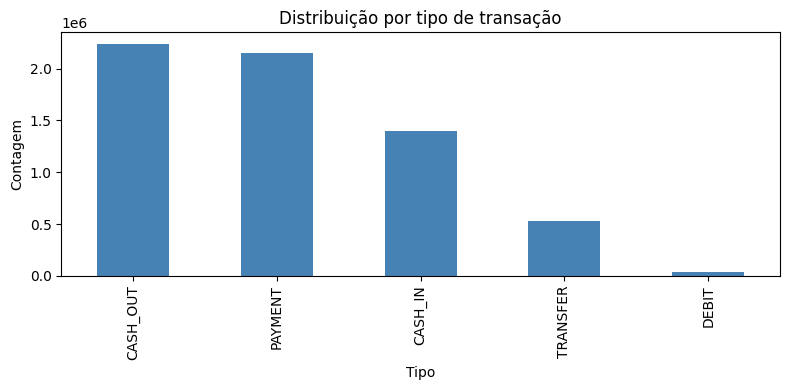

In [23]:
# Distribuição de transações por tipo
print("Transações por tipo:")
print(df['type'].value_counts())

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
df['type'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Distribuição por tipo de transação')
ax.set_xlabel('Tipo')
ax.set_ylabel('Contagem')
plt.tight_layout()
plt.show()

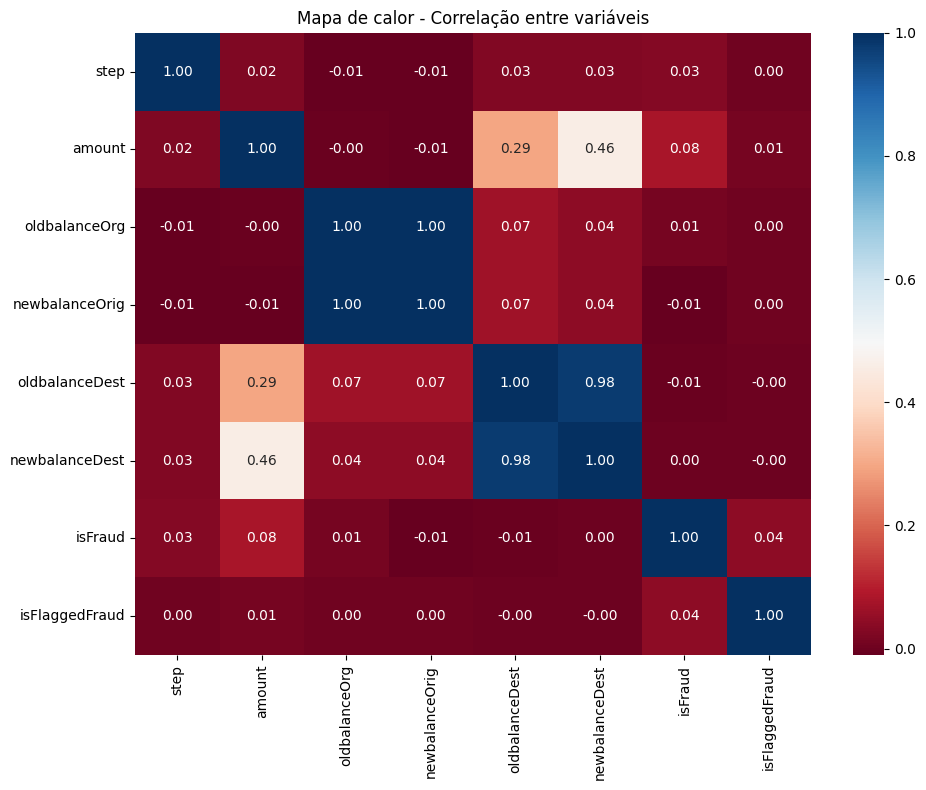

In [24]:
# Correlação entre as variáveis numéricas
df_numeric = df.select_dtypes(include='number')
plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='RdBu', fmt='.2f')
plt.title('Mapa de calor - Correlação entre variáveis')
plt.tight_layout()
plt.show()

#### Pré-processamento dos dados

**Remoção de colunas:**
- `nameOrig` e `nameDest`: identificadores únicos de clientes (strings como "C1231006815"). Não carregam padrão generalizável — cada transação tem nomes distintos, o que causaria overfitting.
- `isFlaggedFraud`: coluna quase constante (~16 flags em 6.3M de transações, ou 0.0003%). Além disso, é derivada de uma regra que tenta detectar fraude (transações > 200k), o que configura potencial data leakage.

**Codificação:**
- `type`: variável categórica convertida via One-Hot Encoding para evitar que o modelo interprete uma ordem inexistente entre os tipos (importante para KNN, que usa distância).

**Normalização:**
- StandardScaler aplicado **após** o split (fit no treino, transform no teste) para evitar data leakage.

In [ ]:
# Remoção de colunas irrelevantes para o modelo

df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'], inplace=True)

# One-Hot Encoding da variável categórica 'type'
df = pd.get_dummies(df, columns=['type'], drop_first=False)

print(f"Shape após pré-processamento: {df.shape}")
df.head()

Shape após pré-processamento: (6362620, 12)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,False,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,False,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,False,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,False,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,False,False,False,True,False


Divisao de treino e teste, 80/20

In [26]:
X = df.drop(columns=["isFraud"])
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalização: fit apenas no treino para evitar data leakage
scaler = StandardScaler()
colunas_numericas = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
X_train[colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])
X_test[colunas_numericas] = scaler.transform(X_test[colunas_numericas])

print(f"Treinamento: {X_train.shape[0]} amostras ({X_train.shape[1]} features)")
print(f"Teste: {X_test.shape[0]} amostras")

# Verificar distribuição das classes no treino
print("\nDistribuição no treino:")
print(y_train.value_counts(normalize=True))

Treinamento: 5090096 amostras (11 features)
Teste: 1272524 amostras

Distribuição no treino:
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


#### Balanceamento das classes (Undersampling)

O dataset é extremamente desbalanceado: apenas **0.13%** das transações são fraude. Isso é problemático para o KNN por dois motivos:

1. **Viés na classificação**: o KNN classifica pelo voto majoritário dos k vizinhos mais próximos. Com ~99.87% de amostras não-fraude, a grande maioria dos vizinhos será sempre da classe 0, fazendo o modelo ignorar fraudes.

2. **Custo computacional**: o KNN calcula a distância para **todos** os pontos de treino. Com ~5M de amostras, o tempo de predição seria inviável.

Aplica-se **Random Undersampling** na classe majoritária (apenas nos dados de treino) para equalizar as classes. O conjunto de teste permanece intocado para refletir a distribuição real.

In [28]:
# Undersampling apenas nos dados de treino
rus = RandomUnderSampler(random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)

print(f"Antes do balanceamento: {X_train.shape[0]} amostras")
print(f"Depois do balanceamento: {X_train_bal.shape[0]} amostras")
print(f"\nDistribuição após balanceamento:")
print(y_train_bal.value_counts())
print(y_train_bal.value_counts(normalize=True))

Antes do balanceamento: 5090096 amostras
Depois do balanceamento: 13140 amostras

Distribuição após balanceamento:
isFraud
0    6570
1    6570
Name: count, dtype: int64
isFraud
0    0.5
1    0.5
Name: proportion, dtype: float64
